# 13 · GNN

Template para `RentalPriceGNN`, con foco en construcción del grafo, evaluación comparable y análisis de qué aprende la red.

## Hipótesis del modelo

- El precio surge de atributos del inmueble y de la estructura relacional entre observaciones cercanas.
- La definición del grafo es parte del modelo y debe documentarse con tanto cuidado como los hiperparámetros.
- La interpretación se apoya más en ablations, embeddings y atención que en importancias clásicas.

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import geopandas as gpd
import seaborn as sns
from sklearn.neighbors import BallTree

PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from ml_core.models.tgnn import TGNN
from ml_core.preprocessing.knhs import KNHS
from ml_core.evaluation.modelEvaluator import regression_metrics
from ml_core.visualization.mapper import (
    plot_residuals_map,
    ZTestMapVisualizer,
    CombinedZLisaMapVisualizer,
)
from ml_core import load_model_config, save_model_config

OUTPUT_DIR = PROJECT_ROOT / "notebooks" / "output" / "13_gnn"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
sns.set_theme(style="whitegrid")


## Datos base

In [3]:
DATA_PATH = PROJECT_ROOT / "data" / "splits"

train_raw = pd.read_csv(DATA_PATH / "arg_venta_data_train.csv")
gdf_train = gpd.GeoDataFrame(
    train_raw,
    geometry=gpd.points_from_xy(
        train_raw["longitud"],
        train_raw["latitud"]
    ),
    crs="EPSG:4326"
)

test_raw = pd.read_csv(DATA_PATH / "arg_venta_data_test.csv")
gdf_test = gpd.GeoDataFrame(
    test_raw,
    geometry=gpd.points_from_xy(
        test_raw["longitud"],
        test_raw["latitud"]
    ),
    crs="EPSG:4326"
)

val_raw = pd.read_csv(DATA_PATH / "arg_venta_data_val.csv")
gdf_val = gpd.GeoDataFrame(
    val_raw,
    geometry=gpd.points_from_xy(
        val_raw["longitud"],
        val_raw["latitud"]
    ),
    crs="EPSG:4326"
)

target_col = "log_precio"   
coord_cols = ["longitud", "latitud"]
feature_cols = [
    'area_m2_cubierta',
    'area_m2_descubierta',
    'ambientes',
    'antiguedad',
    'expensas',
    'banos',
    'cocheras',
    'estado_num',
    'disposicion_Frente',
    'disposicion_Contrafrente',
    'disposicion_Lateral',
    'dist_subte',
    'dist_universidad',
    'dist_hospital',
    'dist_est_educativo',
    'dist_espacio_verde',
    'dist_areas_programaticas',
    'dist_avenida_rivadavia',
    "n_robos_1000m",
    "n_universidades_1000m",
    "pozo",
    "velocidad_ventas_1000m_90d"
]




In [4]:
X_train = gdf_train[feature_cols]
y_train = gdf_train[target_col]
coords_train = gdf_train[coord_cols].to_numpy()

X_test = gdf_test[feature_cols]
y_test = gdf_test[target_col]
coords_test = gdf_test[coord_cols].to_numpy()

X_val = gdf_val[feature_cols]
y_val = gdf_val[target_col]
coords_val = gdf_val[coord_cols].to_numpy()


In [22]:
from ml_core.preprocessing.knhs import KNHS, KNHSSchema, KNHSWeightSpec

# Hyperparámetros de grafo
k_neighbors = 15  # vecinos por nodo para construir aristas
radius_km = 3.0

def build_graph_frame(X_df, coords_deg_longlat):
    """Convierte coords [longitud, latitud] en grados a columnas lat/lon esperadas por KNHS."""
    coords_arr = np.asarray(coords_deg_longlat, dtype=float)
    if coords_arr.ndim != 2 or coords_arr.shape[1] != 2:
        raise ValueError(
            "coords debe tener shape (n, 2) con columnas [longitud, latitud]. "
            f"Recibido: {coords_arr.shape}."
        )

    graph = X_df.copy().reset_index(drop=True)
    graph["lat_deg"] = coords_arr[:, 1]
    graph["lon_deg"] = coords_arr[:, 0]
    return graph


graph_train = build_graph_frame(X_train, coords_train)
graph_val = build_graph_frame(X_val, coords_val)
graph_test = build_graph_frame(X_test, coords_test)

knhs_schema = KNHSSchema(
    lat_col="lat_deg",
    lon_col="lon_deg",
    similarity_feature_cols=[
        "area_m2_cubierta",
        "area_m2_descubierta",
        "ambientes",
        "antiguedad",
        "expensas",
    ],
)


# Este builder se usa como template del modelo. 
builder = KNHS(
    schema=knhs_schema,
    radius_km=radius_km,
    k=k_neighbors,
    feature_distance_mode="euclidean",
    add_reverse=True,
)

edge_index_train, edge_attr_train = builder.build(graph_train)

print("[split-local] Aristas train:", edge_index_train.shape[1])

X_val_cross = pd.concat([X_train.reset_index(drop=True), X_val.reset_index(drop=True)], ignore_index=True)
y_val_cross = pd.concat([y_train.reset_index(drop=True), y_val.reset_index(drop=True)], ignore_index=True)
X_test_cross = pd.concat([X_train.reset_index(drop=True), X_test.reset_index(drop=True)], ignore_index=True)
y_test_cross = pd.concat([y_train.reset_index(drop=True), y_test.reset_index(drop=True)], ignore_index=True)


[split-local] Aristas train: 1339260


## Fine-tuning

Acá barrés hiperparámetros del GNN reutilizando el grafo definido arriba.


## Fine-tuning


In [17]:
config_path = PROJECT_ROOT / "notebooks" / "cache" / "gnn_best_config.json"
saved_config = load_model_config(config_path)
param_grid = {
    "hidden": [64, 96, 128],
    "num_heads": [1, 2, 4],
    "dropout": [0.1, 0.2],
    "lr": [1e-3, 2e-3],
    "weight_decay": [0.0, 1e-4],
    "loss_name": ["huber"],
    "huber_delta": [0.5, 1.0],
    "grad_clip_norm": [None, 5.0],
}

if saved_config is None:
    tuning_model = TGNN(
        feature_names=feature_cols,
        edge_dim=2,
        num_layers=2,
        weight_decay=1e-4,
        patience=50,
        loss_name="huber",
        huber_delta=0.5,
        grad_clip_norm=5.0,
        graph_builder=builder,
    )
    tuning_model.tune_hyperparameters(
        X_train,
        y_train,
        coords_train,
        X_val=X_val,
        y_val=y_val,
        coords_val=coords_val,
        param_grid=param_grid,
        search_type="random",
        n_iter=7,
        optimize_metric="mape",
        epochs=600,
        refit_epochs=6000,
        random_state=42,
    )
    save_model_config(
        tuning_model,
        config_path,
        extra={
            "target": target_col,
            "features": feature_cols,
            "graph_params": {
                "k_neighbors": k_neighbors,
                "radius_km": radius_km,
                "graph_distance": "euclidean",
            },
        },
    )
    saved_config = load_model_config(config_path)
best_config = saved_config.get("best_params_", {})
if not best_config:
    raise ValueError(f"No se encontro best_params_ en {config_path}")
best_config


{'hidden': 64,
 'num_layers': 2,
 'num_heads': 1,
 'dropout': 0.2,
 'lr': 0.002,
 'weight_decay': 0.0,
 'loss_name': 'huber',
 'huber_delta': 0.5,
 'grad_clip_norm': 5.0}

## Entrenamiento


In [7]:
print("Mejor config:", best_config)
print("Cache:", config_path)


Mejor config: {'hidden': 64, 'num_layers': 2, 'num_heads': 1, 'dropout': 0.2, 'lr': 0.002, 'weight_decay': 0.0, 'loss_name': 'huber', 'huber_delta': 0.5, 'grad_clip_norm': 5.0}
Cache: /home/saneliges/Escritorio/PredictorPrecioMetroCuadradoAlquileres/notebooks/cache/gnn_best_config.json


In [23]:
edge_dim = 2  # distancia km + distancia de features (localmente pesada)
model = TGNN(
    feature_names=feature_cols,
    edge_dim=edge_dim,
    graph_builder=builder,
    hidden=int(best_config["hidden"]),
    num_layers=2,
    num_heads=int(best_config["num_heads"]),
    dropout=float(best_config["dropout"]),
    lr=float(best_config["lr"]),
    weight_decay=float(best_config["weight_decay"]),
    patience=600,
    loss_name="mse",
    huber_delta=float(best_config["huber_delta"]),
    grad_clip_norm=(None if best_config["grad_clip_norm"] is None else float(best_config["grad_clip_norm"])),
)
_ = model.fit(
    X_train,
    y_train,
    coords_train,
    epochs=6000,
)
if not model.graph_builder_.edge_scaler_fitted_:
    raise RuntimeError("El edge_scaler del graph_builder no quedó fitted después de fit().")
print("Edge scaler fitted:", model.graph_builder_.edge_scaler_fitted_)
model


Edge scaler fitted: True


TGNN(
  (layers): ModuleList(
    (0): GraphAttentionLayer(
      (W_q): Linear(in_features=22, out_features=64, bias=False)
      (W_k): Linear(in_features=22, out_features=64, bias=False)
      (W_v): Linear(in_features=22, out_features=64, bias=False)
      (W_u): Linear(in_features=2, out_features=64, bias=False)
      (linear_aggr): Linear(in_features=86, out_features=64, bias=True)
      (activation): ReLU()
      (dropout): Dropout(p=0.2, inplace=False)
    )
    (1): GraphAttentionLayer(
      (W_q): Linear(in_features=64, out_features=64, bias=False)
      (W_k): Linear(in_features=64, out_features=64, bias=False)
      (W_v): Linear(in_features=64, out_features=64, bias=False)
      (W_u): Linear(in_features=2, out_features=64, bias=False)
      (linear_aggr): Linear(in_features=128, out_features=64, bias=True)
      (activation): ReLU()
      (dropout): Dropout(p=0.2, inplace=False)
    )
  )
  (readout): Sequential(
    (0): Linear(in_features=64, out_features=64, bias=True

## Evaluación global


In [24]:
y_pred_log = model.predict(
    X_val,
    coords_val,
)

y_pred = np.exp(np.asarray(y_pred_log).reshape(-1))
y_true = np.exp(np.asarray(y_val).reshape(-1))

metrics = regression_metrics(y_true, y_pred)
metrics


{'rmse': 125307.59237532123,
 'mae': 76326.92001038273,
 'r2': 0.03393322577743063,
 'bias': 32164.656049574176,
 'median_abs_error': 47387.703125,
 'mape': 49.59494181443776}

## OOF Outliers

Refactor compartido con `12_rf_kriging`: la deteccion corre sobre folds y solo el armado del modelo/grafo queda especifico del notebook.


In [10]:
from ml_core.preprocessing.knhs import KNHSSchema

from ml_core.outlierAnalysis.oof import (
    detect_outliers_oof,
    load_active_processed_geodata,
)


def build_gnn_model():
    return TGNN(
        feature_names=feature_cols,
        edge_dim=2,
        hidden=int(best_config["hidden"]),
        num_layers=2,
        num_heads=int(best_config["num_heads"]),
        dropout=float(best_config["dropout"]),
        lr=float(best_config["lr"]),
        weight_decay=float(best_config["weight_decay"]),
        patience=50,
        loss_name=str(best_config["loss_name"]),
        huber_delta=float(best_config["huber_delta"]),
        grad_clip_norm=(None if best_config["grad_clip_norm"] is None else float(best_config["grad_clip_norm"])),
        graph_builder=builder,
    )


def gnn_fit_kwargs(context):
    return {}


def gnn_predict_kwargs(context):
    # TGNN construye internamente el grafo cross-split train->target
    # cuando recibe coords en predict(), asi que no necesitamos pasar aristas aca.
    return {}


DATA_PATH = PROJECT_ROOT / "data" / "processed"
barrios_path = PROJECT_ROOT / "GeoData" / "barrios.geojson"

gdf_all = load_active_processed_geodata(
    data_path=DATA_PATH / "arg_venta_data_processed.csv",
    feature_cols=feature_cols,
    target_col=target_col,
    coord_cols=coord_cols,
    extra_cols=["idx", "url", "precio", "area_m2_total"],
)

X_all = gdf_all[feature_cols]
y_all = gdf_all[target_col]
coords_all = gdf_all[coord_cols].to_numpy()

knhs_schema = KNHSSchema(
    lat_col="lat_deg",
    lon_col="lon_deg",
    similarity_feature_cols=list(feature_cols),
)

results_by_method, residuals_oof = detect_outliers_oof(
    model_factory=build_gnn_model,
    X=X_all,
    y=y_all,
    gdf=gdf_all,
    coords=coords_all,
    output_dir=OUTPUT_DIR / "outliers_oof",
    methods=["ztest", "combined_z_lisa"],
    params_for_methods={
        "combined_z_lisa": {
            "alpha": 0.05,
            "permutations": 999,
            "z_threshold": 3.0,
        },
    },
    k_neighbors=15,
    n_splits=5,
    fit_kwargs_resolver=gnn_fit_kwargs,
    predict_kwargs_resolver=gnn_predict_kwargs,
    knhs_schema=knhs_schema,
    knhs_radius_km=radius_km,
    knhs_feature_distance_mode="euclidean",
    knhs_lambda_distance=0.5,
    knhs_bandwidth_mode="adaptive",
    knhs_row_standardize=True,
)

results_by_method["combined_z_lisa"].head()



Fold 1/5

Fold 2/5

Fold 3/5

Fold 4/5
Early stopping en epoch 92, best loss=5.306944

Fold 5/5


,idx,url,fold,method,precio,expensas,area_m2_cubierta,area_m2_descubierta,area_m2_total,antiguedad,...,p_value_lisa,quadrant,combined_score,residuo,is_outlier,valor_observado,valor_predicho,valor_esperado,precio_estimado,precio_observado_modelo
0,41654,https://www.argenprop.com/departamento-en-vent...,1,combined_z_lisa,40000.0,0.0,12.00,0.0,12.0,1.0,...,0.301,LH,0.983067,5.070806,True,10.596660,5.525854,5.525854,251.100714,40001.0
1,63309,https://www.argenprop.com/departamento-en-vent...,1,combined_z_lisa,125000.0,120000.0,131.00,0.0,0.0,65.0,...,0.001,LL,0.000000,6.210223,False,11.736077,5.525854,5.525854,251.100714,125001.0
2,72647,https://www.argenprop.com/departamento-en-vent...,1,combined_z_lisa,75000.0,0.0,33.00,0.0,33.0,0.0,...,0.239,LH,0.816652,5.699403,False,11.225257,5.525854,5.525854,251.100714,75001.0
3,66528,https://www.argenprop.com/departamento-en-vent...,1,combined_z_lisa,99000.0,231000.0,75.91,0.0,79.0,58.0,...,0.595,LH,0.746699,5.977031,False,11.502885,5.525854,5.525854,251.100714,99001.0
4,57197,https://www.argenprop.com/departamento-en-vent...,1,combined_z_lisa,95000.0,247000.0,39.00,0.0,0.0,15.0,...,0.219,LH,0.930529,5.935789,False,11.461643,5.525854,5.525854,251.100714,95001.0


## Residuos espaciales


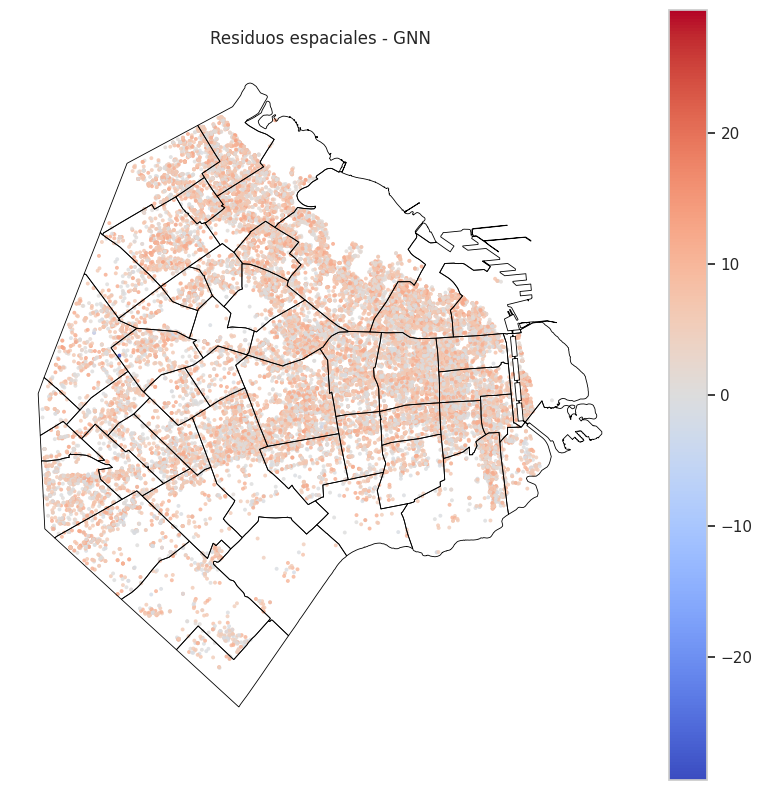

In [11]:
gdf_res = gdf_all.copy()
gdf_res["residual"] = residuals_oof

fig, ax = plot_residuals_map(
    gdf=gdf_res,
    residual_col="residual",
    boundary_path=barrios_path,
    title="Residuos espaciales - GNN",
)


## In sample metrics

In [25]:
y_pred_train_log = model.predict(X_train)

y_pred_train = np.exp(np.asarray(y_pred_train_log).reshape(-1))
y_true_train = np.exp(np.asarray(y_train).reshape(-1))

train_metrics = regression_metrics(y_true_train, y_pred_train)
train_metrics


{'rmse': 125521.88213280933,
 'mae': 76700.35642803092,
 'r2': 0.04615937262889136,
 'bias': 32910.025099769424,
 'median_abs_error': 47859.23046875007,
 'mape': 49.486025182724774}

## Outliers Z-Test


In [13]:
from IPython.display import IFrame, display

z_test_visualizer = ZTestMapVisualizer(
    gdf_all=gdf_all,
    results_df=results_by_method["ztest"],
    barrios_path=PROJECT_ROOT / "GeoData" / "barrios.geojson",
    filter_config={
        "precio": {"kind": "numeric", "label": "Precio"},
        "ambientes": {"kind": "numeric", "label": "Ambientes"},
        "area_m2_cubierta": {"kind": "numeric", "label": "Metros cuadrados"},
        "pozo": {
            "kind": "boolean",
            "label": "En pozo",
            "boolean_labels": {
                "all": "Todos",
                "true": "Solo en pozo",
                "false": "Solo no en pozo",
            },
        },
    },
    popup_fields=[
        "precio",
        "precio_estimado",
        "area_m2_cubierta",
        "area_m2_descubierta",
        "ambientes",
        "pozo",
        "p_value_z",
        "residuo",
        "url",
    ],
)

z_test_map = z_test_visualizer.build_map()
z_test_map_path = OUTPUT_DIR / "outliers_oof" / "z_test_interactive_map.html"
z_test_visualizer.save_map(z_test_map_path)
display(IFrame(src=str(z_test_map_path.relative_to(PROJECT_ROOT)), width="100%", height=700))


## Outliers Combined Z + LISA


In [14]:
from IPython.display import IFrame, display

combined_z_lisa_visualizer = CombinedZLisaMapVisualizer(
    gdf_all=gdf_all,
    results_df=results_by_method["combined_z_lisa"],
    barrios_path=PROJECT_ROOT / "GeoData" / "barrios.geojson",
    filter_config={
        "precio": {"kind": "numeric", "label": "Precio"},
        "ambientes": {"kind": "numeric", "label": "Ambientes"},
        "area_m2_cubierta": {"kind": "numeric", "label": "Metros cuadrados"},
        "pozo": {
            "kind": "boolean",
            "label": "En pozo",
            "boolean_labels": {
                "all": "Todos",
                "true": "Solo en pozo",
                "false": "Solo no en pozo",
            },
        },
        "quadrant": {
            "kind": "categorical",
            "label": "Cuadrante LISA",
            "categories": {
                "HH": "Alto-Alto",
                "LL": "Bajo-Bajo",
                "HL": "Alto-Bajo",
                "LH": "Bajo-Alto"},
                }
    },
    popup_fields=[
        "precio",
        "precio_estimado",
        "area_m2_cubierta",
        "area_m2_descubierta",
        "ambientes",
        "pozo",
        "p_value_z",
        "residuo",
        "url",
    ],
)
combined_z_lisa_map = combined_z_lisa_visualizer.build_map()
combined_z_lisa_map_path = OUTPUT_DIR / "outliers_oof" / "combined_z_lisa_interactive_map.html"
combined_z_lisa_visualizer.save_map(combined_z_lisa_map_path)
display(IFrame(src=str(combined_z_lisa_map_path.relative_to(PROJECT_ROOT)), width="100%", height=700))
